# Structural Similarity: MCS and Tanimoto Fingerprints
**File:** `structural_similarity_mcs.ipynb` (renamed from `Untitled.ipynb`)

## Purpose
Explores structural similarity between compounds using RDKit: Maximum Common Substructure (MCS) and Morgan fingerprint Tanimoto similarity. Motivated by the need to understand when two compounds are true structural isomers vs coincidental spectral overlaps.

## What is done
- Computes Morgan fingerprint Tanimoto similarity between candidate pairs
- Runs MCS (rdFMCS) to find maximum common substructure
- Identifies true structural isomers (same molecular formula, high Tanimoto)
- Links structural similarity to entropy similarity scores

## Status: EXPLORATORY
Not integrated into the scoring pipeline. Results inform the isomer analysis in `channel_ceiling.ipynb` (Step 1c).

## Key finding
Many high-similarity spectral pairs are NOT structural isomers — coincidental spectral overlap is common. MCS computation is slow; Tanimoto on Morgan fingerprints is a practical proxy.


In [66]:
import os
import pandas as pd
import numpy as np
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
import random
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import ms_entropy as me
import random
import numpy as np
import ast


In [67]:

# Standard mapping 
standard_mapping = {
    "name": "Name",
    "ion_mode": "Ion Mode",
    "instrument": "Instrument",
    "instrument_type": "Instrument Type",
    "ionization": "Ionization",
    "collision_energy": "Collision Energy",
    "collision_gas": "Collision Gas",
    "sample_inlet": "Sample Inlet",
    "spectrum_type": "Spectrum Type",
    "precursor_type": "Precursor Type",
    "precursormz": "Precursor M/Z",
    "notes": "Notes",
    "inchikey": "InChIKey",
    "smiles": "SMILES",
    "synon": "Synonyms",
    "formula": "Formula",
    "mw": "Molecular Weight",
    "exactmass": "Exact Mass",
    "cas#": "CAS Number",
    "nist#": "NIST Number",
    "db#": "Database ID",
    "comments": "Comments",
    "unique_scan_number": "Unique Scan Number",
    "spectrum_id": "Spectrum ID",
    "num peaks": "Num Peaks"
}


def standardize_col(df):
    """
    Standardizes column names in the given DataFrame based on a provided mapping.
    
    Args:
        df (pd.DataFrame): The DataFrame whose column names need to be standardized.

    Returns:
        pd.DataFrame: DataFrame with standardized column names.
    """
    new_columns = []
    for col in df.columns:
        col_lower = col.lower().replace("reference_", "")
        standardized_col = standard_mapping.get(col_lower, col_lower)
        new_columns.append(standardized_col)
    df.columns = new_columns
    return df

def remove_zero_ions(msms):
    """
    Removes zero-intensity ions from an MS/MS spectrum.
    
    Args:
        msms (numpy.ndarray or float): MS/MS spectrum in 2D numpy array.
    
    Returns:
        numpy.ndarray: Filtered 2D array with non-zero intensities.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[msms[:, 1] > 0]

def sort_spectrum(msms):
    """
    Sorts MS/MS peaks by m/z value.
    
    Args:
        msms (numpy.ndarray): 2D numpy array with [m/z, intensity].
    
    Returns:
        numpy.ndarray: Sorted 2D array.
    """
    if isinstance(msms, float) or len(msms) == 0:
        return np.nan
    return msms[np.argsort(msms[:, 0])]

def read_msp(file_path):
    """
    Parses an MSP file and extracts MS/MS spectra into a structured pandas DataFrame.
    
    Args:
        file_path (str): Path to the MSP file.

    Returns:
        pd.DataFrame: Parsed MS/MS spectra with metadata.
    """

    spectra = []
    spectrum = {}

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                continue  # Skip empty lines

            # Identify metadata fields
            if ":" in line:
                key, value = line.split(":", 1)
                key, value = key.strip().lower(), value.strip()

                if key == 'name':
                    # Save the previous spectrum before starting a new one
                    if spectrum:
                        spectra.append(spectrum)
                    spectrum = {'name': value, 'peaks': []}  # Start new spectrum entry
                
                else:
                    spectrum[key] = value  # Store metadata fields
            
            # Parse peak data (if line starts with a number, it's peak data)
            elif line[0].isdigit():
                try:
                    m_z, intensity = map(float, line.split()[:2])
                    spectrum['peaks'].append([m_z, intensity])
                except ValueError:
                    continue  # Ignore malformed lines

        # Save the last spectrum
        if spectrum:
            spectra.append(spectrum)

    # Convert spectra list to DataFrame
    df = pd.DataFrame(spectra)

    # Process peaks: Remove zero-intensity ions & sort by m/z
    df['peaks'] = [sort_spectrum(remove_zero_ions(np.array(peak))) for peak in df['peaks']]

    # Standardize column names
    df = standardize_col(df)

    # Convert numeric columns where applicable
    for column in df.columns:
        if column != 'peaks':  # Skip 'peaks' column
            try:
                df[column] = pd.to_numeric(df[column], errors='ignore')
            except:
                pass

    return df

# file_path = "/Users/ellayoung/Desktop/metabolo_confi_score/data/nist23-raw.msp"
# df = read_msp(file_path)

# Display parsed data
# print(df.head())
# df.info()
# Save to CSV
# df.to_csv("parsed_spectra.csv", index=False)
df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')
df.info()



# Subset the DataFrame to only include the specified precursor types + have an inchikey + unique values

df_unique = df.drop_duplicates(subset=['InChIKey'], keep='first')
df_unique = df_unique[df_unique["Precursor Type"].isin(["[M+H]+", "[M-H]-"])]
df_unique = df_unique.dropna(subset=['InChIKey'])
df_unique.info()

<ipython-input-67-c105d169255c>:154: DtypeWarning: Columns (11,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/ellayoung/Desktop/metabolo_confi_score/parsed_spectra.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1934658 entries, 0 to 1934657
Data columns (total 31 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Name                object 
 1   peaks               object 
 2   Ion Mode            object 
 3   Instrument          object 
 4   Instrument Type     object 
 5   Ionization          object 
 6   Collision Energy    object 
 7   Collision Gas       object 
 8   Sample Inlet        object 
 9   Spectrum Type       object 
 10  Precursor Type      object 
 11  Precursor M/Z       object 
 12  Notes               object 
 13  InChIKey            object 
 14  SMILES              object 
 15  Synonyms            object 
 16  Formula             object 
 17  Molecular Weight    int64  
 18  Exact Mass          float64
 19  CAS Number          object 
 20  NIST Number         int64  
 21  Database ID         int64  
 22  Comments            object 
 23  Unique Scan Number  int64  
 24  Spectrum ID         int6

In [3]:

# # Convert NaN or float SMILES to empty strings and ensure dtype is string
df_unique["SMILES"] = df_unique["SMILES"].fillna("").astype(str)

# Create a helper column with the first 14 characters of InChIKey
df_unique["inchi14"] = df_unique["InChIKey"].astype(str).str[:14]

df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39592 entries, 0 to 1934633
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                39592 non-null  object 
 1   peaks               39592 non-null  object 
 2   Ion Mode            39592 non-null  object 
 3   Instrument          39592 non-null  object 
 4   Instrument Type     39592 non-null  object 
 5   Ionization          39592 non-null  object 
 6   Collision Energy    39592 non-null  object 
 7   Collision Gas       39592 non-null  object 
 8   Sample Inlet        39592 non-null  object 
 9   Spectrum Type       39592 non-null  object 
 10  Precursor Type      39592 non-null  object 
 11  Precursor M/Z       39592 non-null  object 
 12  Notes               39592 non-null  object 
 13  InChIKey            39592 non-null  object 
 14  SMILES              39592 non-null  object 
 15  Synonyms            38522 non-null  object 
 16  Formula

In [ ]:

# import signal
# import time
# from rdkit import Chem
# from rdkit.Chem import DataStructs, rdFMCS
# from rdkit.Chem.rdFingerprintGenerator import GetRDKitFPGenerator
# import itertools

# # Function to enforce time limit on MCS computation
# class TimeoutException(Exception):
#     pass

# def timeout_handler(signum, frame):
#     raise TimeoutException()

# signal.signal(signal.SIGALRM, timeout_handler)  # Register timeout handler

# def one_bond_difference(mol1, mol2):
#     """Check if two molecules differ by exactly one bond using MCS with pre-filters."""
#     if not mol1 or not mol2:
#         return False

#     # Pre-filter 1: Bond count difference >1 → Skip
#     if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
#         return False

#     # Pre-filter 2: Tanimoto fingerprint similarity < 0.9 → Skip
#     fp1, fp2 = GetRDKitFPGenerator().GetFingerprint(mol1), GetRDKitFPGenerator().GetFingerprint(mol2)
#     if DataStructs.TanimotoSimilarity(fp1, fp2) < 0.9:
#         return False
    
#     print(f")
#     # Start the 30s timeout
#     signal.alarm(30)

#     try:
#         # Compute MCS
#         mcs_start = time.time()
#         mcs = rdFMCS.FindMCS([mol1, mol2], bondCompare=rdFMCS.BondCompare.CompareOrderExact, matchValences=True)
#         mcs_time = time.time() - mcs_start

#         # Disable alarm if successful
#         signal.alarm(0)

#         print(f"  → MCS Time: {mcs_time:.4f}s for this pair")

#         common = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
#         return common and mol1.GetNumBonds() - common.GetNumBonds() == 1 and mol2.GetNumBonds() - common.GetNumBonds() == 1

#     except TimeoutException:
#         print(f"⚠️ WARNING: MCS computation exceeded 30s for this pair. Skipping...")
#         signal.alarm(0)  # Reset alarm
#         return False

# # Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different)
# isomer_pairs_filtered = []

# for _, group in grouped:
#     if len(group) > 1:
#         for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
#             if row1["inchi14"] != row2["inchi14"]:  # Different first 14 InChIKeys
#                 mol1, mol2 = Chem.MolFromSmiles(row1["SMILES"]), Chem.MolFromSmiles(row2["SMILES"])

#                 # Ensure valid molecules before checking one-bond difference
#                 if mol1 and mol2 and not one_bond_difference(mol1, mol2):
#                     isomer_pairs_filtered.append((row1, row2))

# print(f"Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different): {len(isomer_pairs_filtered)}")


In [5]:
import signal
import time
from rdkit import Chem
from rdkit.Chem import DataStructs, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import itertools

grouped = df_unique.groupby(["Formula"])

# Function to enforce time limit on MCS computation
class TimeoutException(Exception):
    pass

def timeout_handler(signum, frame):
    raise TimeoutException()

signal.signal(signal.SIGALRM, timeout_handler)  # Register timeout handler

def one_bond_difference(mol1, mol2):
    """Check if two molecules differ by exactly one bond using an optimized MCS with pre-filters."""
    if not mol1 or not mol2:
        return False

    # Pre-filter 1: Bond count difference >1 → Skip
    if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
        return False

    # Pre-filter 2: Tanimoto fingerprint similarity < 0.9 → Skip
    fp_gen = GetMorganGenerator(radius=2, fpSize=1024)  # Use new RDKit API
    fp1, fp2 = fp_gen.GetFingerprint(mol1), fp_gen.GetFingerprint(mol2)

    if DataStructs.TanimotoSimilarity(fp1, fp2) < 0.9:
        return False

    # Start the 30s timeout
    signal.alarm(30)

    try:
        # Compute MCS with optimized parameters
        mcs_start = time.time()
        mcs = rdFMCS.FindMCS(
            [mol1, mol2],
            bondCompare=rdFMCS.BondCompare.CompareAny,  # Faster bond comparison
            atomCompare=rdFMCS.AtomCompare.CompareAny,  # Loosen atom comparison
            ringMatchesRingOnly=True,  # Match rings only to rings
            completeRingsOnly=False,  # Allow partial ring matches
            timeout=10  # Force stop after 10 seconds
        )
        mcs_time = time.time() - mcs_start

        # Disable alarm if successful
        signal.alarm(0)

        print(f"  → MCS Time: {mcs_time:.4f}s for this pair")

        common = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
        return common and mol1.GetNumBonds() - common.GetNumBonds() == 1 and mol2.GetNumBonds() - common.GetNumBonds() == 1

    except TimeoutException:
        print(f"⚠️ WARNING: MCS computation exceeded 10s for this pair. Skipping...")
        signal.alarm(0)  # Reset alarm
        return False

# Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different)
isomer_pairs_filtered = []

for _, group in grouped:
    if len(group) > 1:
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            if len(isomer_pairs_filtered) >= 10000:  # Stop when 10000 pairs are collected
                break

            if row1["inchi14"] != row2["inchi14"]:  # Different first 14 InChIKeys
                mol1, mol2 = Chem.MolFromSmiles(row1["SMILES"]), Chem.MolFromSmiles(row2["SMILES"])

                # Ensure valid molecules before checking one-bond difference
                if mol1 and mol2 and not one_bond_difference(mol1, mol2):
                    isomer_pairs_filtered.append((row1, row2))

    if len(isomer_pairs_filtered) >= 10000:  # Stop outer loop as well
        break

print(f"Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different): {len(isomer_pairs_filtered)}")


  → MCS Time: 0.0001s for this pair
  → MCS Time: 0.0000s for this pair
  → MCS Time: 0.0000s for this pair
  → MCS Time: 0.0001s for this pair
  → MCS Time: 0.0000s for this pair
  → MCS Time: 0.0000s for this pair
  → MCS Time: 0.0007s for this pair
  → MCS Time: 0.0053s for this pair
  → MCS Time: 0.0109s for this pair
Filtered isomer pairs (Same formula, different InChIKey, NOT one-bond different): 10000


In [8]:
def parse_peaks_string(peaks_str):
    """
    Parse a peaks string like:
    '[[136.0435   3.4   ]\n [214.9619  38.4   ]\n ...]'
    into a list of lists of floats.
    """
    # Remove the outer brackets and any leading/trailing whitespace
    cleaned = peaks_str.strip("[] \n")
    # Split into lines (each line corresponds to one peak row)
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        # Remove any remaining brackets and extra whitespace
        row_clean = row.strip(" []")
        if row_clean:
            # Split on whitespace and convert each element to float
            values = row_clean.split()
            result.append([float(val) for val in values])
    return result

def safe_parse_peaks(peaks):
    """
    If peaks is a string, parse it. Otherwise, assume it is already parsed.
    """
    if isinstance(peaks, str):
        return parse_peaks_string(peaks)
    return peaks

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100):
    """
    Compute a null distribution of similarity scores from filtered isomer pairs,
    stratified by spectral entropy.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    for spec1, spec2 in isomer_pairs:
        peaks1_raw, peaks2_raw = spec1.get("peaks"), spec2.get("peaks")

        # Ensure peaks are parsed properly
        parsed_peaks1 = safe_parse_peaks(peaks1_raw)
        parsed_peaks2 = safe_parse_peaks(peaks2_raw)

        if parsed_peaks1 and parsed_peaks2:
            spec1["peaks"] = parsed_peaks1
            spec2["peaks"] = parsed_peaks2

            # Compute spectral entropy
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                     clean_spectrum=True,
                                                     min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    print("\nEntropy-based groups:")
    for entropy, pairs in entropy_groups.items():
        print(f"  - Entropy {entropy}: {len(pairs)} pairs")

    # Bootstrap sampling for the null distribution
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs
        
        for _ in range(num_bootstrap):
            selected_pairs = random.choices(pairs, k=num_pairs) if len(pairs) < num_pairs else random.sample(pairs, num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1["peaks"], spec2["peaks"], ms2_tolerance_in_da=0.05)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)

    return null_distributions




Entropy-based groups:
  - Entropy 0: 5826 pairs
  - Entropy 1: 3790 pairs
  - Entropy 3: 41 pairs
  - Entropy 2: 341 pairs
  - Entropy 4: 2 pairs


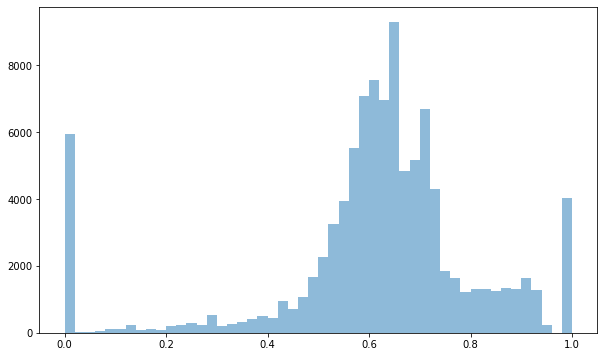

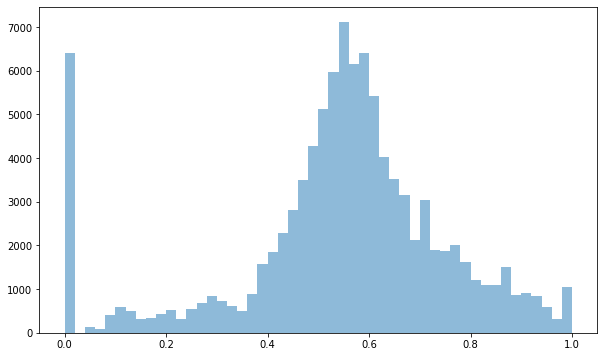

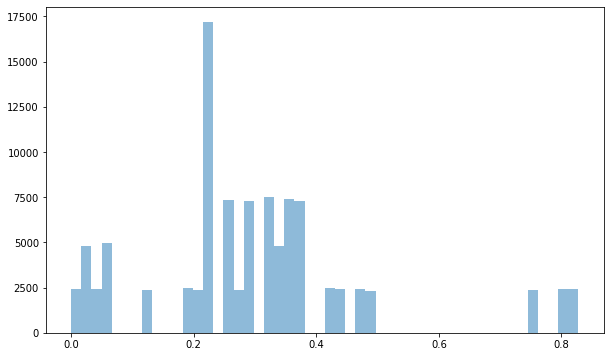

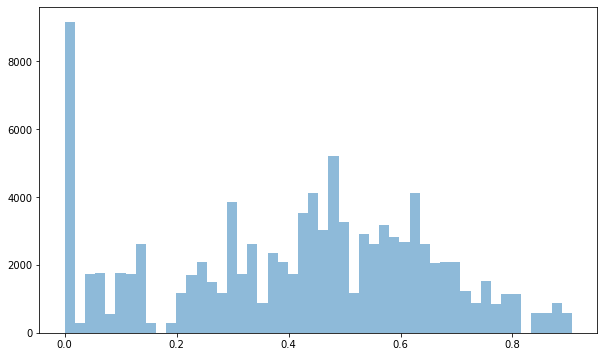

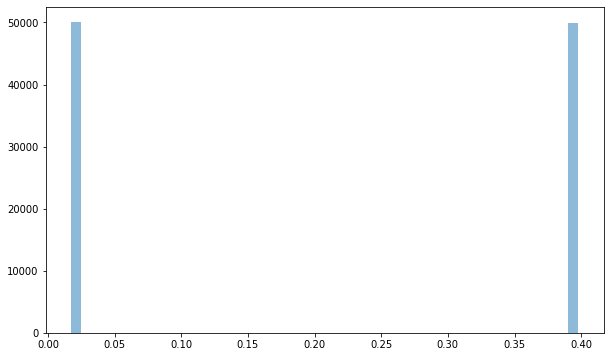

In [10]:

null_distribution = compute_random_similarity(isomer_pairs_filtered, num_pairs=100, num_bootstrap=1000)



# Iterate through entropy groups and plot histograms
for entropy, scores in null_distribution.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.5, label=f"Entropy {entropy}")


# Null with one bond different isomers

In [17]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity


# Create a helper column with the first 14 characters of InChIKey
df_unique['inchi14'] = df_unique['InChIKey'].str[:14]

# Group by "Precursor M/Z" and "Formula"
grouped = df_unique.groupby(["Formula"])

# List to hold the isomer pairs
isomer_pairs = []

# Iterate over each group
for _, group in grouped:
    # Only consider groups with at least two entries
    if len(group) > 1:
        # Generate all unique pairs within the group
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            # Check if the first 14 characters of InChIKey differ
            if row1["inchi14"] != row2["inchi14"]:
                isomer_pairs.append((row1, row2))

# isomer_pairs now contains tuples of rows (each tuple is a pair of isomers)
print(f"Found {len(isomer_pairs)} isomer pairs meeting the criteria.")

from rdkit import Chem
from rdkit.DataStructs import FingerprintSimilarity
from rdkit.Chem import AllChem

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity




def parse_peaks_string(peaks_str):
    """
    Parse a peaks string like:
    '[[136.0435   3.4   ]\n [214.9619  38.4   ]\n ...]'
    into a list of lists of floats.
    """
    # Remove the outer brackets and any leading/trailing whitespace
    cleaned = peaks_str.strip("[] \n")
    # Split into lines (each line corresponds to one peak row)
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        # Remove any remaining brackets and extra whitespace
        row_clean = row.strip(" []")
        if row_clean:
            # Split on whitespace and convert each element to float
            values = row_clean.split()
            result.append([float(val) for val in values])
    return result

def safe_parse_peaks(peaks):
    """
    If peaks is a string, parse it. Otherwise, assume it is already parsed.
    """
    if isinstance(peaks, str):
        return parse_peaks_string(peaks)
    return peaks


def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        # Update the dictionaries so that the peaks are stored in parsed format
        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        # # Debug: print the types and content of parsed peaks
        # print("Parsed peaks types:", type(parsed_peaks1), type(parsed_peaks2))
        # print("Parsed peaks content:", parsed_peaks1, parsed_peaks2)

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            # Compute the entropy from the first spectrum's peaks (converted to a NumPy array)
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                      clean_spectrum=True,
                                                      min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    for entropy, pairs in entropy_groups.items():
        print(f"Entropy group {entropy} has {len(pairs)} pairs")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs
        
        for _ in range(num_bootstrap):
            if len(pairs) < num_pairs:
                selected_pairs = random.choices(pairs, k=num_pairs)
            else:
                selected_pairs = random.sample(pairs, num_pairs)

            scores = [
                me.calculate_entropy_similarity(spec1['peaks'], spec2['peaks'], ms2_tolerance_in_da = 10)
                for spec1, spec2 in selected_pairs
            ]
            null_distributions[entropy].extend(scores)


    return null_distributions


Found 78552 isomer pairs meeting the criteria.


In [18]:
ms2_tolerance_in_da = 10
null_w_one_bond_isomers = compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100)

Entropy group 0 has 44598 pairs
Entropy group 1 has 30020 pairs
Entropy group 3 has 654 pairs
Entropy group 2 has 3216 pairs
Entropy group 4 has 64 pairs


# Benchmark adjusted sim score with orig sim score

In [ ]:
import numpy as np
import pandas as pd
import ms_entropy
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.stats import percentileofscore


# Step 1: Compute Raw Entropy Similarity Scores
def compute_raw_entropy_similarity(df_spectra):
    """
    Compute raw entropy similarity scores by searching each spectrum against others.

    Parameters:
    - df_spectra (DataFrame): Spectra dataset containing precursor m/z, peaks, and entropy levels.

    Returns:
    - DataFrame with added column `score_entropy`, `entropy_level`, and `correct`.
    """
    df_spectra = df_spectra.rename(columns={"Precursor M/Z": "precursor_mz"})
    df_spectra["precursor_mz"] = df_spectra["precursor_mz"].astype(float)

    all_results = []
    precursor_mz_array = df_spectra["precursor_mz"].to_numpy(dtype=np.float32)
    df_spectra = df_spectra.sort_values(by="precursor_mz")

    for idx, row in df_spectra.iterrows():
        precursor_mz = row["precursor_mz"]
        peaks_raw = row["peaks"]
        inchi14 = row["inchi14"]
        spec_id = row["Spectrum ID"]
        entropy_level = row["entropy_level"]  # Ensure entropy level is carried forward

        # Parse peaks
        peaks = np.array(safe_parse_peaks(peaks_raw), dtype=np.float32)

        precursor_mz_left = precursor_mz * (1 - MS1_TOLERANCE_IN_PPM / 1e6)
        precursor_mz_right = precursor_mz * (1 + MS1_TOLERANCE_IN_PPM / 1e6)

        candidate_idx_left = np.searchsorted(precursor_mz_array, precursor_mz_left, side="left")
        candidate_idx_right = np.searchsorted(precursor_mz_array, precursor_mz_right, side="right")

        for candidate_idx in range(candidate_idx_left, candidate_idx_right):
            if candidate_idx == idx:
                continue  # Skip self-matching

            candidate_row = df_spectra.iloc[candidate_idx]
            candidate_peaks_raw = candidate_row["peaks"]
            candidate_peaks = np.array(safe_parse_peaks(candidate_peaks_raw), dtype=np.float32)

            entropy_similarity = ms_entropy.calculate_entropy_similarity(peaks, candidate_peaks, ms2_tolerance_in_da=0.05)

            # Determine if this is a correct match
            correct = int(inchi14 == candidate_row["inchi14"])

            all_results.append([
                spec_id, inchi14, candidate_row["Spectrum ID"], candidate_row["inchi14"],
                entropy_similarity, entropy_level, correct
            ])

    df_results = pd.DataFrame(all_results, columns=[
        "spec_id_query", "inchi14_query", "spec_id_library", "inchi14_library",
        "score_entropy", "entropy_level", "correct"
    ])
    return df_results


df_results = compute_raw_entropy_similarity(df_result)

# Keep the highest-scoring match per query **and retain entropy_level**
df_results = df_results.sort_values(by="score_entropy", ascending=False)
df_top_1 = df_results.groupby("spec_id_query").first().reset_index()

# Verify that entropy_level exists now
print(df_top_1.info())  # Should show entropy_level column


In [54]:
import numpy as np
from scipy.stats import percentileofscore

import numpy as np
from scipy.stats import percentileofscore

def compute_adjusted_scores(df, null_distribution):
    """
    Compute null-adjusted entropy similarity scores using empirical p-values.

    Parameters:
    - df (DataFrame): Contains `score_entropy` and `entropy_level`.
    - null_distribution (dict): Null similarity score distributions grouped by entropy level.

    Returns:
    - DataFrame with `score_entropy_adjusted` added (values between 0 and 1).
    """
    adjusted_scores = []

    for _, row in df.iterrows():
        entropy_level = row["entropy_level"]  # Use rounded entropy level
        score_obs = row["score_entropy"]

        if entropy_level in null_distribution:
            null_scores = np.array(null_distribution[entropy_level])

            # Compute empirical p-value: P(X >= score_obs)
            p_value = 1 - (percentileofscore(null_scores, score_obs, kind="rank") / 100)

            # Adjusted similarity score: 1 - p-value (keeps range 0-1)
            score_adjusted = max(0, min(1, 1 - p_value))  # Ensure within [0,1]
        else:
            score_adjusted = np.nan  # Handle missing entropy levels in null distribution

        adjusted_scores.append(score_adjusted)

    df["score_entropy_adjusted"] = adjusted_scores
    return df

# Apply null-adjusted score computation
df_top_1 = compute_adjusted_scores(df_top_1, null_w_one_bond_isomers)


In [55]:
df_top_1

,spec_id_query,inchi14_query,spec_id_library,inchi14_library,score_entropy,entropy_level,correct,score_entropy_adjusted
0,1134039,JVJFIQYAHPMBBX,1065622,XSQUKJJJFZCRTK,0.000000,0,0,0.01230
1,1273899,KMXXSJLYVJEBHI,1065159,ZRALSGWEFCBTJO,0.135317,1,0,0.04320
2,1360363,CVSVTCORWBXHQV,1065159,ZRALSGWEFCBTJO,0.000000,0,0,0.01230
3,1453593,OQZGYMRYZAKXAF,1065622,XSQUKJJJFZCRTK,0.000000,1,0,0.02100
4,1464033,HTVITOHKHWFJKO,1464033,HTVITOHKHWFJKO,1.000000,1,1,0.99190
5,1465651,OALYTRUKMRCXNH,1065622,XSQUKJJJFZCRTK,0.000000,0,0,0.01230
6,1468173,CAWFCZIEFIQKRV,1468173,CAWFCZIEFIQKRV,1.000000,1,1,0.99190
7,1472535,PXRBWNLUQYZAAX,1065622,XSQUKJJJFZCRTK,0.000000,0,0,0.01230
8,1801857,ZGZVGZCIFZBNCN,1801857,ZGZVGZCIFZBNCN,1.000000,0,1,0.97545
9,1835196,YOUWVLSTAZVPHM,1835196,YOUWVLSTAZVPHM,1.000000,1,1,0.98350


In [56]:

# Step 3: Compute ROC Curves
y_true = df_top_1["correct"].astype(int)

# Compute ROC for Raw Entropy Similarity
fpr_raw, tpr_raw, _ = roc_curve(y_true, df_top_1["score_entropy"])
roc_auc_raw = auc(fpr_raw, tpr_raw)

# Compute ROC for Null-Adjusted Entropy Similarity
fpr_adj, tpr_adj, _ = roc_curve(y_true, df_top_1["score_entropy_adjusted"])
roc_auc_adj = auc(fpr_adj, tpr_adj)



In [59]:
fpr_raw

array([0.        , 0.        , 0.        , 0.07407407, 1.        ])

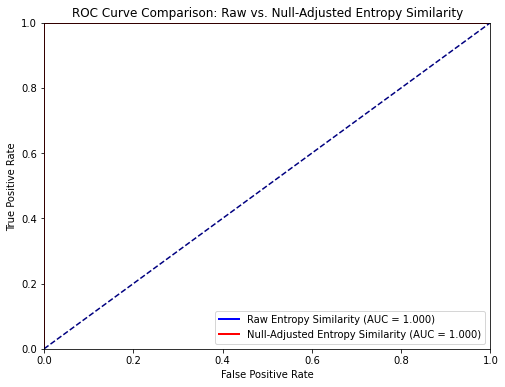

In [57]:

# Step 4: Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_raw, tpr_raw, color="blue", lw=2, label=f"Raw Entropy Similarity (AUC = {roc_auc_raw:.3f})")
plt.plot(fpr_adj, tpr_adj, color="red", lw=2, label=f"Null-Adjusted Entropy Similarity (AUC = {roc_auc_adj:.3f})")
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Diagonal baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Raw vs. Null-Adjusted Entropy Similarity")
plt.legend(loc="lower right")
plt.show()

In [60]:

# Step 5: Compare FPR at Fixed TPR
tpr_thresholds = [0.80, 0.90]  # Compare at TPR = 80% and 90%
fpr_comparison = {}

for threshold in tpr_thresholds:
    idx_raw = np.argmin(np.abs(tpr_raw - threshold))
    idx_adj = np.argmin(np.abs(tpr_adj - threshold))

    fpr_comparison[threshold] = {
        "FPR (Raw Entropy)": fpr_raw[idx_raw],
        "FPR (Null-Adjusted)": fpr_adj[idx_adj]
    }

# Convert to DataFrame and Display
df_fpr_comparison = pd.DataFrame.from_dict(fpr_comparison, orient="index")



In [61]:
df_fpr_comparison

,FPR (Raw Entropy),FPR (Null-Adjusted)
0.8,0.0,0.0
0.9,0.0,0.0


In [24]:
print(df_unique.columns)


Index(['Name', 'peaks', 'Ion Mode', 'Instrument', 'Instrument Type',
       'Ionization', 'Collision Energy', 'Collision Gas', 'Sample Inlet',
       'Spectrum Type', 'Precursor Type', 'Precursor M/Z', 'Notes', 'InChIKey',
       'SMILES', 'Synonyms', 'Formula', 'Molecular Weight', 'Exact Mass',
       'CAS Number', 'NIST Number', 'Database ID', 'Comments',
       'Unique Scan Number', 'Spectrum ID', 'Num Peaks', 'related_cas#',
       'in-source_voltage', 'msn_pathway', 'peptide_sequence', 'peptide_mods',
       'inchi14'],
      dtype='object')


In [20]:
import numpy as np
from scipy.stats import percentileofscore
from collections import defaultdict

def compute_p_values(observed_scores, null_distribution):
    """
    Compute p-values for observed similarity scores based on the null distribution.

    Parameters:
        observed_scores (list of tuples): List of (entropy_level, similarity_score).
        null_distribution (dict): Dictionary of entropy_level -> list of null similarity scores.

    Returns:
        dict: Dictionary of adjusted similarity scores {entropy_level: [(score, p-value, adjusted_score)]}.
    """
    adjusted_scores = defaultdict(list)
    
    for entropy_level, S_obs in observed_scores:
        if entropy_level not in null_distribution or len(null_distribution[entropy_level]) == 0:
            continue  # Skip if no null data for this entropy level

        # Get the null distribution for the given entropy level
        null_scores = np.array(null_distribution[entropy_level])

        # Compute empirical p-value
        p_value = 1 - (percentileofscore(null_scores, S_obs, kind="rank") / 100)

        # Transform p-value into an adjusted similarity score
        adjusted_similarity = -np.log10(p_value) if p_value > 0 else np.inf  # Avoid log(0)
        
        adjusted_scores[entropy_level].append((S_obs, p_value, adjusted_similarity))

    return adjusted_scores


In [7]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity


# Create a helper column with the first 14 characters of InChIKey
df_unique['inchi14'] = df_unique['InChIKey'].str[:14]

# Group by "Precursor M/Z" and "Formula"
grouped = df_unique.groupby(["Formula"])

# List to hold the isomer pairs
isomer_pairs = []

# Iterate over each group
for _, group in grouped:
    # Only consider groups with at least two entries
    if len(group) > 1:
        # Generate all unique pairs within the group
        for (idx1, row1), (idx2, row2) in itertools.combinations(group.iterrows(), 2):
            # Check if the first 14 characters of InChIKey differ
            if row1["inchi14"] != row2["inchi14"]:
                isomer_pairs.append((row1, row2))

# isomer_pairs now contains tuples of rows (each tuple is a pair of isomers)
print(f"Found {len(isomer_pairs)} isomer pairs meeting the criteria.")

from rdkit import Chem
from rdkit.DataStructs import FingerprintSimilarity
from rdkit.Chem import AllChem

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.DataStructs import TanimotoSimilarity

def compute_tanimoto_similarity(smiles1, smiles2):
    """
    Compute the Tanimoto similarity between two molecules given their SMILES.
    """
    # Ensure input is a string
    smiles1 = str(smiles1).strip()
    smiles2 = str(smiles2).strip()

    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    if mol1 and mol2:
        # Create a Morgan fingerprint generator with radius 2 and 2048-bit size
        morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
        fp1 = morgan_gen.GetFingerprint(mol1)
        fp2 = morgan_gen.GetFingerprint(mol2)
        return TanimotoSimilarity(fp1, fp2)
    
    return None  # Return None if SMILES conversion fails



def parse_peaks_string(peaks_str):
    """
    Parse a peaks string like:
    '[[136.0435   3.4   ]\n [214.9619  38.4   ]\n ...]'
    into a list of lists of floats.
    """
    # Remove the outer brackets and any leading/trailing whitespace
    cleaned = peaks_str.strip("[] \n")
    # Split into lines (each line corresponds to one peak row)
    rows = cleaned.split('\n')
    result = []
    for row in rows:
        # Remove any remaining brackets and extra whitespace
        row_clean = row.strip(" []")
        if row_clean:
            # Split on whitespace and convert each element to float
            values = row_clean.split()
            result.append([float(val) for val in values])
    return result

def safe_parse_peaks(peaks):
    """
    If peaks is a string, parse it. Otherwise, assume it is already parsed.
    """
    if isinstance(peaks, str):
        return parse_peaks_string(peaks)
    return peaks

def compute_random_similarity(isomer_pairs, num_pairs=100, num_bootstrap=100):
    """
    Compute a null distribution of similarity scores from isomer pairs,
    stratified by the entropy of the first spectrum in each pair.

    Parameters:
      isomer_pairs (list of tuples): List of (spectrum1, spectrum2) isomer pairs.
      num_pairs (int): Number of random pairs to sample per entropy group per bootstrap iteration.
      num_bootstrap (int): Number of bootstrap iterations to stabilize similarity estimates.

    Returns:
      dict: Null distributions of similarity scores grouped by spectral entropy.
    """
    entropy_groups = defaultdict(list)

    # Group isomer pairs by the rounded entropy of the first spectrum
    for spec1, spec2 in isomer_pairs:
        peaks1_raw = spec1.get('peaks')
        peaks2_raw = spec2.get('peaks')

        try:
            parsed_peaks1 = safe_parse_peaks(peaks1_raw)
            parsed_peaks2 = safe_parse_peaks(peaks2_raw)
        except Exception as e:
            print(f"Error parsing peaks: {e}")
            continue

        # Update the dictionaries so that the peaks are stored in parsed format
        spec1['peaks'] = parsed_peaks1
        spec2['peaks'] = parsed_peaks2

        # # Debug: print the types and content of parsed peaks
        # print("Parsed peaks types:", type(parsed_peaks1), type(parsed_peaks2))
        # print("Parsed peaks content:", parsed_peaks1, parsed_peaks2)

        if isinstance(parsed_peaks1, (list, np.ndarray)) and isinstance(parsed_peaks2, (list, np.ndarray)):
            # Compute the entropy from the first spectrum's peaks (converted to a NumPy array)
            entropy1 = me.calculate_spectral_entropy(np.array(parsed_peaks1, dtype=np.float32),
                                                      clean_spectrum=True,
                                                      min_ms2_difference_in_da=0.05)
            entropy_group = round(entropy1)
            entropy_groups[entropy_group].append((spec1, spec2))

    for entropy, pairs in entropy_groups.items():
        print(f"Entropy group {entropy} has {len(pairs)} pairs")

    # Create the null distributions by bootstrapping from each entropy group
    null_distributions = defaultdict(list)

    for entropy, pairs in entropy_groups.items():
        if len(pairs) < 2:
            continue  # Skip groups with too few pairs
        
        for _ in range(num_bootstrap):
            if len(pairs) < num_pairs:
                selected_pairs = random.choices(pairs, k=num_pairs)
            else:
                selected_pairs = random.sample(pairs, num_pairs)

            scores = [
                compute_tanimoto_similarity(str(spec1.get('SMILES', '')).strip(), str(spec2.get('SMILES', '')).strip())
                for spec1, spec2 in selected_pairs
                if isinstance(spec1.get('SMILES'), str) and isinstance(spec2.get('SMILES'), str)  # Ensure SMILES are strings
            ]


            null_distributions[entropy].extend(scores)

    return null_distributions



Found 78552 isomer pairs meeting the criteria.


Entropy group 0 has 44598 pairs
Entropy group 1 has 30020 pairs
Entropy group 3 has 654 pairs
Entropy group 2 has 3216 pairs
Entropy group 4 has 64 pairs


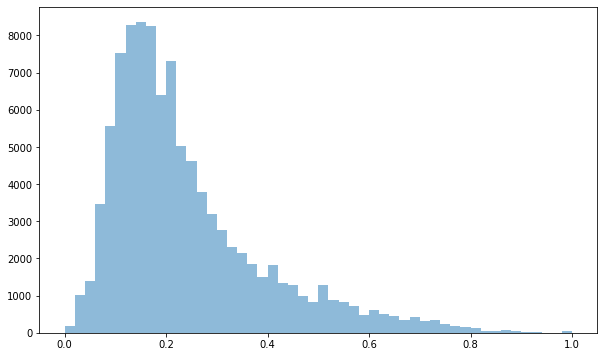

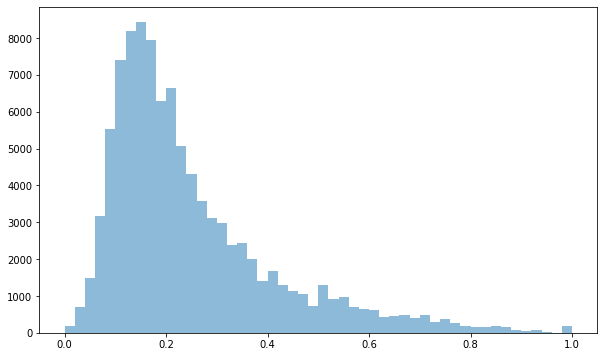

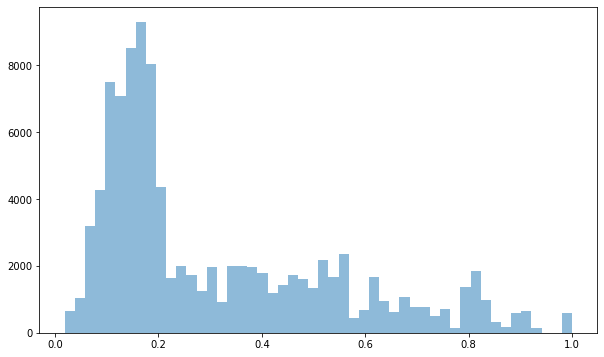

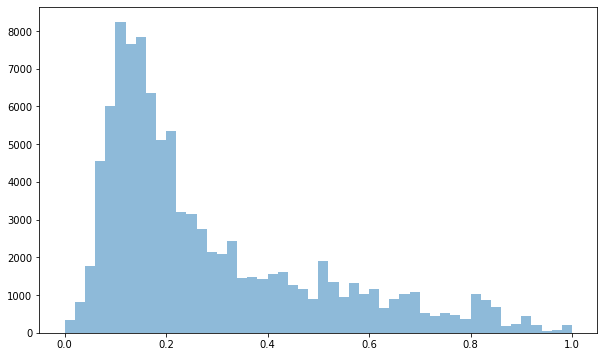

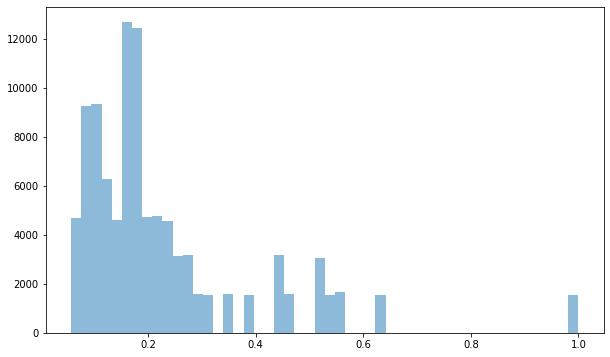

In [8]:



tanimoto_null_distribution = compute_random_similarity(isomer_pairs, num_pairs=1000, num_bootstrap=100)



for entropy, scores in tanimoto_null_distribution.items():
    plt.figure(figsize=(10, 6))
    plt.hist(scores, bins=50, alpha=0.5, label=f"Entropy {entropy}")


In [1]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFMCS, RDKFingerprint
import pandas as pd
import itertools
from collections import defaultdict
from joblib import Parallel, delayed


In [17]:
import time
from rdkit import Chem, DataStructs
import pandas as pd
import itertools
from collections import defaultdict
from rdkit.Chem.Scaffolds import MurckoScaffold

def is_one_bond_different(mol1, mol2):
    """Check if two molecules are similar but differ by one bond using Murcko scaffolds."""
    if not mol1 or not mol2:
        return False

    # **Pre-filter 1**: Bond count difference >1 → Skip
    if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
        return False

    # **Murcko Scaffold Matching (Instead of Substructure Matching)**
    scaffold1 = MurckoScaffold.GetScaffoldForMol(mol1)
    scaffold2 = MurckoScaffold.GetScaffoldForMol(mol2)
    return scaffold1.HasSubstructMatch(scaffold2) or scaffold2.HasSubstructMatch(scaffold1)


def group_by_formula_and_mz(df, mz_tolerance=0.002):
    """Group spectra by Formula and cluster within ±2 mDa of Precursor M/Z."""
    
    print("Grouping spectra by Formula and M/Z...")
    start_time = time.time()

    # **Step 1: Drop missing values**
    df = df.dropna(subset=['SMILES', 'Formula', 'Precursor M/Z'])
    df['Precursor M/Z'] = df['Precursor M/Z'].astype(float)  # Ensure numeric

    # **Step 2: Group by Formula first**
    grouped = []
    for formula, group in df.groupby('Formula'):
        group = group.sort_values(by='Precursor M/Z')  # Sort for efficient clustering
        
        # **Step 3: Cluster spectra within ±2 mDa**
        mz_clusters = []
        current_cluster = [group.iloc[0]]

        for i in range(1, len(group)):
            prev_mz = current_cluster[-1]['Precursor M/Z']
            current_mz = group.iloc[i]['Precursor M/Z']

            if abs(current_mz - prev_mz) <= mz_tolerance:
                current_cluster.append(group.iloc[i])
            else:
                mz_clusters.append(pd.DataFrame(current_cluster))  # Store cluster
                current_cluster = [group.iloc[i]]  # Start new cluster

        # Store last cluster
        if current_cluster:
            mz_clusters.append(pd.DataFrame(current_cluster))

        grouped.extend(mz_clusters)

    print(f"Grouping completed in {time.time() - start_time:.4f}s | Total groups: {len(grouped)}")
    return grouped


def find_true_isomers(df):
    """Find pairs of molecules differing by one bond using Murcko scaffolds & improved grouping."""
    start_time = time.time()
    true_isomer_pairs = []

    # **Step 1: Group by Formula and cluster by Precursor M/Z ±2 mDa**
    formula_mz_groups = group_by_formula_and_mz(df, mz_tolerance=0.002)

    # **Step 2: Process each group**
    for group_df in formula_mz_groups:
        if len(group_df) < 2:
            continue  # Skip single-molecule groups

        print(f"Processing {len(group_df)} molecules for formula {group_df['Formula'].iloc[0]}...")

        # Convert SMILES → Mol **only once**
        group_df['Mol'] = group_df['SMILES'].apply(lambda smi: Chem.MolFromSmiles(smi) if pd.notna(smi) else None)
        group_df = group_df.dropna(subset=['Mol'])

        if group_df.empty:
            continue  # Skip empty groups after Mol conversion

        # **Step 3: Generate valid Mol object pairs within each cluster**
        mol_records = group_df.to_dict('records')
        pairs = [(s1['Mol'], s2['Mol'], s1, s2) for s1, s2 in itertools.combinations(mol_records, 2)]

        print(f"Processing {len(pairs)} pairs for formula {group_df['Formula'].iloc[0]}...")

        # Check pairs with Murcko Scaffold matching
        for mol1, mol2, spec1, spec2 in pairs:
            if is_one_bond_different(mol1, mol2):
                true_isomer_pairs.append((spec1, spec2))

    print(f"Total execution time: {time.time() - start_time:.4f}s")
    return true_isomer_pairs


In [ ]:

# df_short = df_unique
# true_isomers = find_true_isomers(df_short)  
# print(f"Found {len(true_isomers)} true isomer pairs.")

In [35]:
import numpy as np
import re

def parse_spectrum(spectrum):
    """
    Parses a spectrum dictionary to extract and format MS/MS peaks.

    Parameters:
    spectrum (dict): A dictionary containing spectrum data.

    Returns:
    dict: Parsed spectrum with a NumPy array of peaks, or None if parsing fails.
    """
    try:
        peaks_raw = spectrum.get('peaks', None)

        if not isinstance(peaks_raw, str):
            print(f"Skipping: Invalid peaks format for {spectrum.get('Name', 'Unknown')} (Type: {type(peaks_raw)})")
            return None

        # **Fix Formatting Issues**
        cleaned_peaks = re.sub(r'\s+', ' ', peaks_raw).strip()  # Remove excessive spaces and newlines

        # **Ensure Correct Syntax for eval()**
        cleaned_peaks = cleaned_peaks.replace(" ", ", ")  # Ensure proper comma-separated format

        # **Convert String to NumPy Array**
        peaks = np.array(eval(cleaned_peaks), dtype=np.float32)  # Convert string to list and cast to NumPy array

        # **Ensure it's in the correct 2D format (m/z, intensity)**
        if peaks.ndim != 2 or peaks.shape[1] != 2:
            print(f"Skipping: Peaks not in expected 2D format for {spectrum.get('Name', 'Unknown')}")
            return None

        # **Store the parsed peaks back into the spectrum dictionary**
        spectrum['peaks'] = peaks
        return spectrum

    except Exception as e:
        print(f"Error parsing spectrum {spectrum.get('Name', 'Unknown')}: {e}")
        return None


def parse_tp_pairs(tp_pairs):
    """
    Parses and formats a list of TP isomer pairs for compute_tp_similarity().

    Parameters:
    tp_pairs (list of tuples): List of (spectrum1, spectrum2) TP isomer pairs.

    Returns:
    list: Parsed TP pairs with properly formatted peaks.
    """
    parsed_pairs = []
    
    for spec1, spec2 in tp_pairs:
        parsed_spec1 = parse_spectrum(spec1)
        parsed_spec2 = parse_spectrum(spec2)
        
        if parsed_spec1 and parsed_spec2:
            parsed_pairs.append((parsed_spec1, parsed_spec2))
    
    return parsed_pairs


In [ ]:


# Parse TP pairs
parsed_tp_pairs = parse_tp_pairs(true_isomers)

# Now use it with compute_tp_similarity()
tp_distributions = compute_tp_similarity(parsed_tp_pairs)


In [ ]:
print(type(true_isomers))  # Should be a list
print(type(true_isomers[0]))  # Should be a tuple
print(type(true_isomers[0][0]), type(true_isomers[0][1]))  # Should both be dict
print(len(true_isomers))  # Should print the number of TP pairs
print(true_isomers[:2])  # Print first two pairs for inspection


In [59]:
import time
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFMCS, RDKFingerprint
import pandas as pd
import itertools
from collections import defaultdict

def one_bond_difference(mol1, mol2):
    """Check if two molecules differ by exactly one bond using MCS with pre-filters."""
    if not mol1 or not mol2:
        return False

    # Pre-filter 1: Bond count difference >1 → Skip
    if abs(mol1.GetNumBonds() - mol2.GetNumBonds()) > 1:
        return False

    # Pre-filter 2: Tanimoto fingerprint similarity < 0.8 → Skip
    fp1, fp2 = RDKFingerprint(mol1), RDKFingerprint(mol2)
    if DataStructs.FingerprintSimilarity(fp1, fp2) < 0.8:
        return False

    # Compute MCS and log time
    mcs_start = time.time()
    mcs = rdFMCS.FindMCS([mol1, mol2], bondCompare=rdFMCS.BondCompare.CompareOrderExact, matchValences=True)
    mcs_time = time.time() - mcs_start

    print(f"  → MCS Time: {mcs_time:.4f}s for this pair")

    common = Chem.MolFromSmarts(mcs.smartsString) if mcs.smartsString else None
    return common and mol1.GetNumBonds() - common.GetNumBonds() == 1 and mol2.GetNumBonds() - common.GetNumBonds() == 1


def find_true_isomers(df):
    """Find pairs of molecules differing by one bond (Optimized with debug logs)."""
    start_time = time.time()
    true_isomer_pairs = []
    precursor_groups = defaultdict(list)

    # **Step 1**: Group molecules by rounded Precursor M/Z
    print("Grouping spectra by Precursor M/Z...")
    for _, row in df.iterrows():
        if pd.notna(row['SMILES']) and pd.notna(row['Precursor M/Z']) and pd.notna(row['Formula']):
            precursor_groups[round(float(row['Precursor M/Z']), 2)].append(row)
    print(f"Grouping completed in {time.time() - start_time:.4f}s")

    # **Step 2**: Convert SMILES → Mol **only once**
    for precursor, spectra in precursor_groups.items():
        print(f"Processing precursor M/Z: {precursor} with {len(spectra)} spectra...")

        spectra_df = pd.DataFrame(spectra)
        spectra_df['Mol'] = spectra_df['SMILES'].apply(lambda smi: Chem.MolFromSmiles(smi) if pd.notna(smi) else None)

        # **Filter out invalid molecules**
        spectra_df = spectra_df.dropna(subset=['Mol'])
        if spectra_df.empty:
            print(f"Skipping precursor M/Z {precursor}: No valid molecules.")
            continue

        # **Step 3**: Generate valid Mol object pairs within each formula group
        for formula, group in spectra_df.groupby('Formula'):
            if len(group) < 2:
                print(f"Skipping formula {formula} in precursor {precursor}: Only {len(group)} molecule(s).")
                continue

            mol_records = group.to_dict('records')
            pairs = [(s1['Mol'], s2['Mol'], s1, s2) for s1, s2 in itertools.combinations(mol_records, 2)]

            print(f"Processing {len(pairs)} pairs for formula {formula} in precursor {precursor}...")

            if not pairs:
                print(f"Warning: No valid pairs found for Formula: {formula} in precursor {precursor}.")

            # Check pairs with MCS
            for i, (mol1, mol2, spec1, spec2) in enumerate(pairs):
                print(f"Checking pair {i+1}/{len(pairs)} in formula {formula}...")  # Now starts at 1 instead of 0
                try:
                    result = one_bond_difference(mol1, mol2)
                    if result:
                        true_isomer_pairs.append((spec1, spec2))
                        print(f"✅ Pair {i+1} confirmed as true isomer!")
                    else:
                        print(f"❌ Pair {i+1} does not meet one-bond difference criteria.")
                except Exception as e:
                    print(f"⚠️ Error processing pair {i+1}: {e}")


    print(f"Total execution time: {time.time() - start_time:.4f}s")
    return true_isomer_pairs


In [ ]:

df_short = df_unique[:2000]
true_isomers = find_true_isomers(df_short)  
print(f"Found {len(true_isomers)} true isomer pairs.")